## Imports

In [59]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from collections import Counter

# For Proyecto 3
# from sklearn.model_selection import train_test_split
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.feature_extraction.text import CountVectorizer

## 1. Introducción teórica
• Explique brevemente qué son los mensajes spam y ham.

• Comente por qué es relevante diferenciarlos y cómo se puede aplicar la clasificación automática en este contexto.


### Que es el spam y el ham?
El spam se refiere a mensajes no solicitados, que se envían en grandes cantidades a través de medios electrónicos, como el correo electrónico o los mensajes de texto. Estos mensajes suelen ser molestos y pueden contener publicidad, estafas o contenido malicioso.

El ham, por otro lado, se refiere a mensajes legítimos y deseados que no son spam. Estos mensajes pueden ser correos electrónicos personales, mensajes de texto entre amigos o cualquier comunicación que no sea considerada como spam.

### Relevancia de diferenciar entre spam y ham
Diferenciar entre spam y ham es crucial para mejorar la experiencia del usuario y proteger la seguridad en línea. La clasificación automática de mensajes permite filtrar el spam de manera eficiente, evitando que los usuarios reciban mensajes no deseados y reduciendo el riesgo de caer en estafas o malware.

## 2. Carga y exploración de los datos (EDA) Realice un análisis exploratorio inicial del dataset:
• Cargue el dataset en Python.

• Muestre 5 mensajes aleatorios.

• Genere las siguientes visualizaciones:

    o Cantidad total de mensajes.
    o Distribución y proporción de mensajes spam vs ham.
    o Gráfica de densidad de la longitud de los mensajes spam.
    o Gráfica de densidad de la longitud de los mensajes ham.
    o Top 20 palabras más frecuentes en mensajes spam.
    o Top 20 palabras más frecuentes en mensajes ham.
    o Visualización de palabras clave usando WordCloud para cada clase.


In [60]:
# open the csv file and read it into a pandas dataframe
df = pd.read_csv("Data/SpamHam.csv", encoding="latin-1", sep=";")

print("Number of rows in the dataframe:", len(df))

# Show 5 random rows of the dataframe
random.seed(1234)
df_sample = df.sample(n=5)
df_sample

Number of rows in the dataframe: 5564


,Label,SMS_TEXT
4026,ham,Lol its ok I didn't remember til last nite
3684,ham,I get out of class in bsn in like &lt
4197,spam,"cmon babe, make me horny, *turn* me on! Txt me..."
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
2575,ham,Hey whats up? U sleeping all morning?


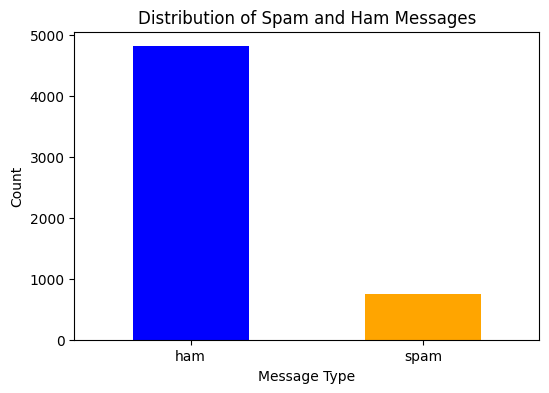

In [61]:
# Show the number of spam and ham messages in the dataset
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

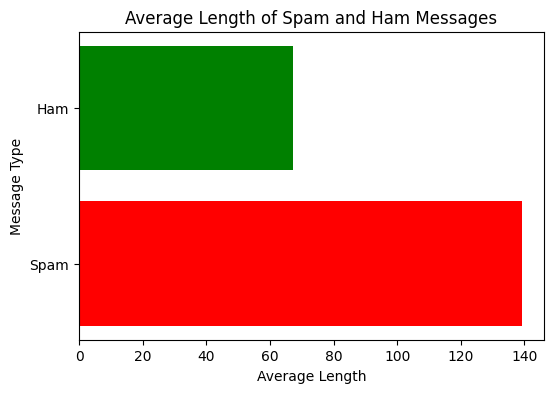

In [62]:
# Length of the avg spam and ham messages
plt.figure(figsize=(6, 4))
df["Message_Length"] = df["SMS_TEXT"].fillna("").astype(str).apply(len)
avg_length_spam = df[df["Label"] == "spam"]["Message_Length"].mean()
avg_length_ham = df[df["Label"] == "ham"]["Message_Length"].mean()

plt.barh(["Spam", "Ham"], [avg_length_spam, avg_length_ham], color=["red", "green"])
plt.title("Average Length of Spam and Ham Messages")
plt.xlabel("Average Length")
plt.ylabel("Message Type")
plt.show()

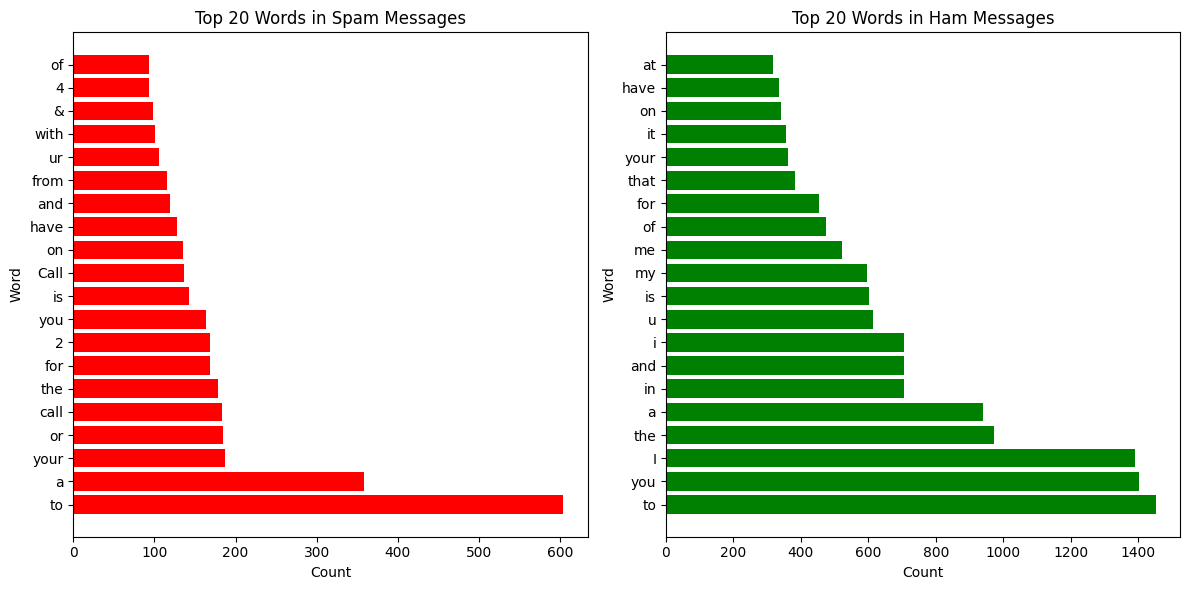

In [63]:
# Top 20 most common words in spam and ham messages
def get_top_words(messages, n=20):
    all_words = " ".join(messages).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)
top_spam_words = get_top_words(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
top_ham_words = get_top_words(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh([word for word, count in top_spam_words], [count for word, count in top_spam_words], color="red")
plt.title("Top 20 Words in Spam Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.subplot(1, 2, 2)
plt.barh([word for word, count in top_ham_words], [count for word, count in top_ham_words], color="green")
plt.title("Top 20 Words in Ham Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

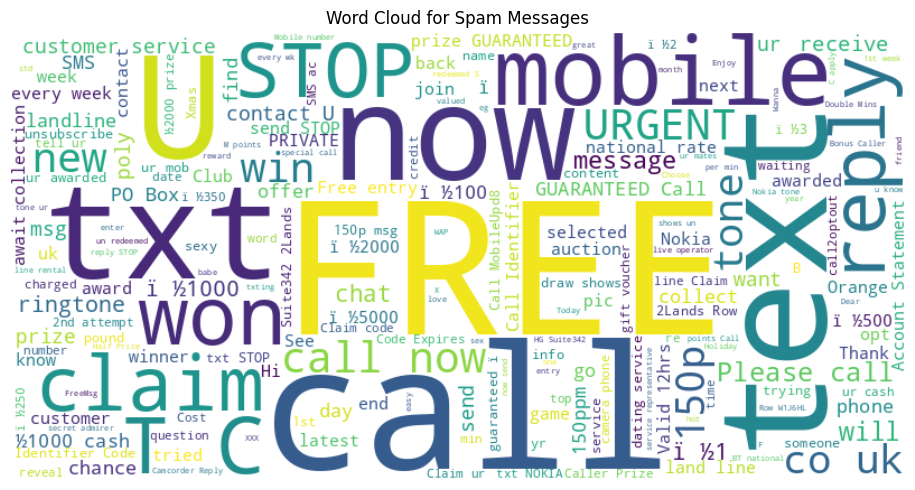

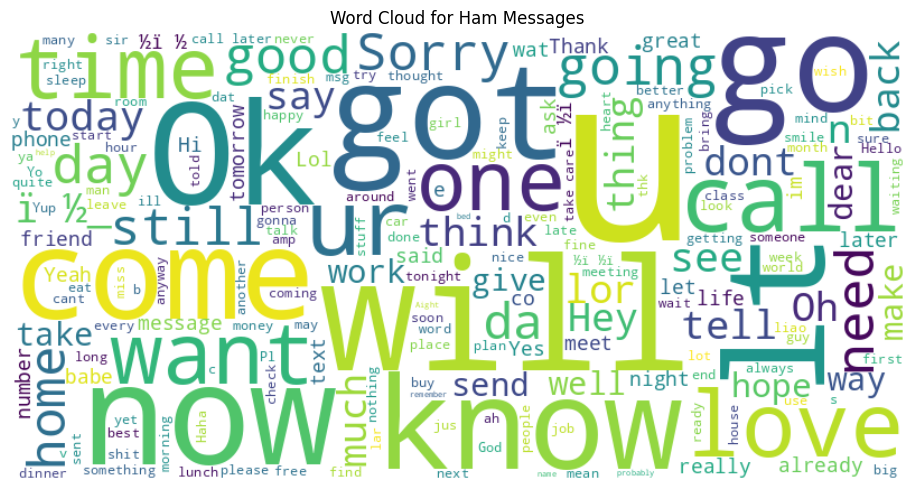

In [64]:
# Show keywords of spam and ham using word clouds
from wordcloud import WordCloud
spam_text = " ".join(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
ham_text = " ".join(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))
spam_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(spam_text)
ham_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(12, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Spam Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Ham Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de texto
Utilizando el modulo de python NLTK, aplique las siguientes transformaciones al texto, explicando qué hace cada una y por qué es útil:

**Tokenización:** Divide cada mensaje en una lista de palabras (tokens) individuales. Es el primer paso necesario para procesar el texto de forma granular.

**Conversión a minúsculas:** Normaliza el texto para que "FREE" y "free" sean tratadas como la misma palabra, reduciendo la dimensionalidad del vocabulario.

**Eliminación de signos de puntuación:** Remueve caracteres no alfanuméricos (`.`, `!`, `?`, etc.) que no aportan información semántica útil para la clasificación.

**Eliminación de stopwords:** Elimina palabras muy frecuentes del idioma ("the", "is", "and", etc.) que aparecen por igual en spam y ham y no ayudan a diferenciar entre clases.

**Stemming (PorterStemmer):** Reduce cada palabra a su raíz morfológica (e.g., "running" → "run", "winner" → "winner"). Se eligió stemming sobre lemmatización porque es más rápido, no requiere corpus adicional (como WordNet), y para clasificación de spam la raíz aproximada es suficiente para capturar el significado relevante.

In [65]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Tokenization
df["SMS_TEXT"] = df["SMS_TEXT"].fillna("").astype(str).apply(word_tokenize)

# Lowercase
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word.lower() for word in x])

# Remove punctuation
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word for word in x if word.isalnum()])

# Remove stopwords
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [word for word in x if word not in stop_words])

# Stemming
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: [stemmer.stem(word) for word in x])

# Join tokens back into a string for later vectorization
df["SMS_TEXT"] = df["SMS_TEXT"].apply(lambda x: ' '.join(x))

## 4. Análisis posterior al preprocesamiento
Una vez preprocesado el texto, vuelva a realizar los análisis del punto 2 con el dataset
transformado:

• Cantidad total de mensajes.

• Proporción de spam vs ham.

• Gráficas de densidad de longitud (spam y ham).

• Top 20 palabras más frecuentes en cada clase.

• WordCloud para cada clase.

In [66]:
# Show length of the cleaned dataframe
print("Number of rows in the cleaned dataframe:", len(df))

# Show 5 random rows of the cleaned dataframe
random.seed(1234)
df_sample_cleaned = df.sample(n=5)
df_sample_cleaned


Number of rows in the cleaned dataframe: 5564


,Label,SMS_TEXT,Message_Length
2857,ham,know god creat gap finger one made come amp,99
3135,ham,right think,45
5050,spam,free video camera phone half price line rental...,145
4216,ham,actual wait 2 week start put ad,60
1910,ham,real tho suck ca even cook whole electr hungri,87


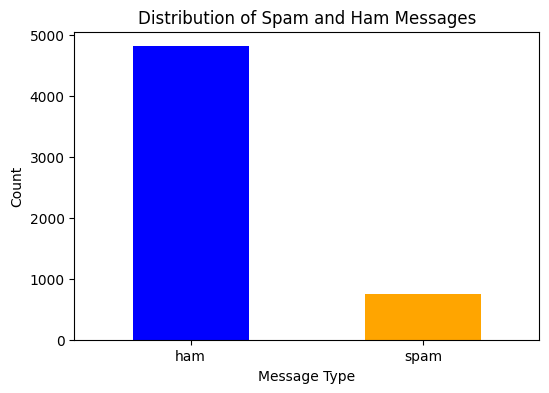

In [67]:
# Show the number of spam and ham messages in the dataset
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["blue", "orange"])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

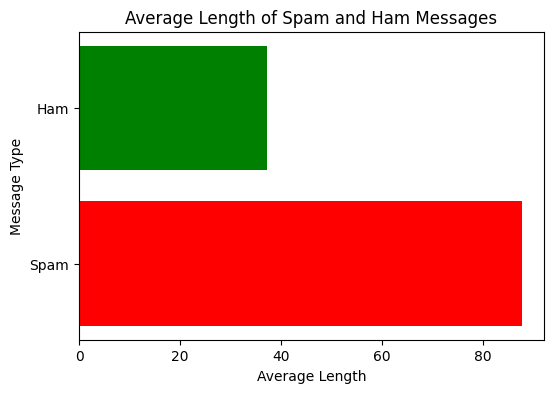

In [68]:
# Length of the avg spam and ham messages
plt.figure(figsize=(6, 4))
df["Message_Length"] = df["SMS_TEXT"].fillna("").astype(str).apply(len)
avg_length_spam = df[df["Label"] == "spam"]["Message_Length"].mean()
avg_length_ham = df[df["Label"] == "ham"]["Message_Length"].mean()

plt.barh(["Spam", "Ham"], [avg_length_spam, avg_length_ham], color=["red", "green"])
plt.title("Average Length of Spam and Ham Messages")
plt.xlabel("Average Length")
plt.ylabel("Message Type")
plt.show()

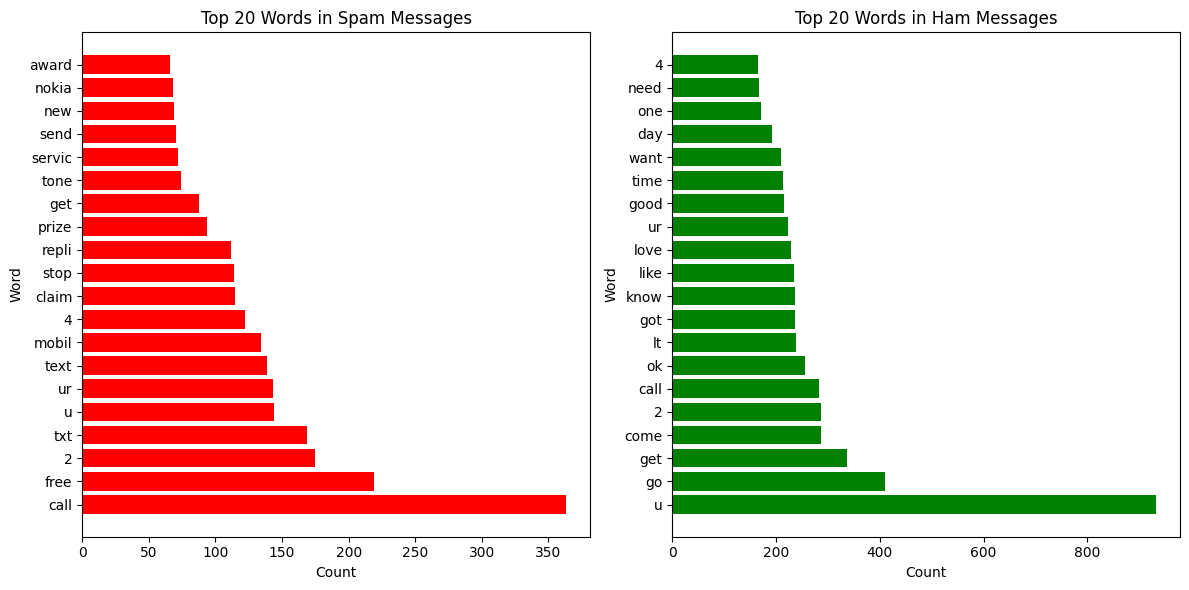

In [69]:
# Top 20 most common words in spam and ham messages
def get_top_words(messages, n=20):
    all_words = " ".join(messages).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)
top_spam_words = get_top_words(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
top_ham_words = get_top_words(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh([word for word, count in top_spam_words], [count for word, count in top_spam_words], color="red")
plt.title("Top 20 Words in Spam Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.subplot(1, 2, 2)
plt.barh([word for word, count in top_ham_words], [count for word, count in top_ham_words], color="green")
plt.title("Top 20 Words in Ham Messages")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

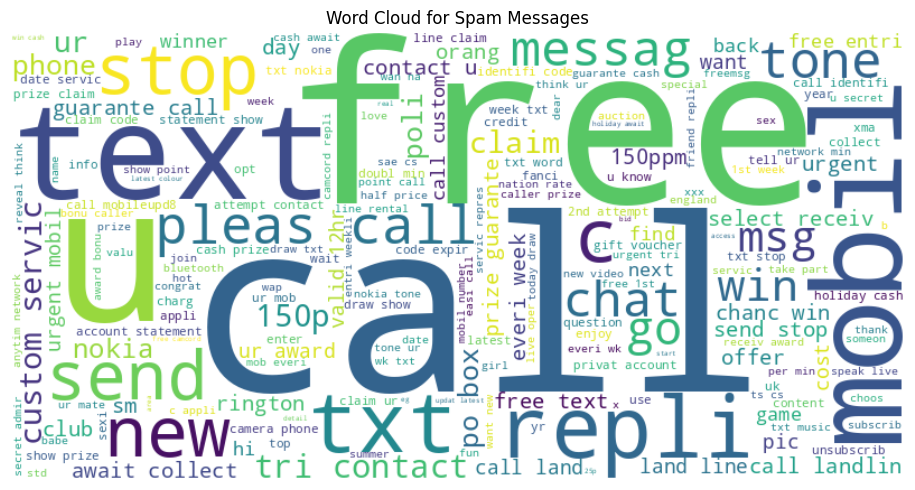

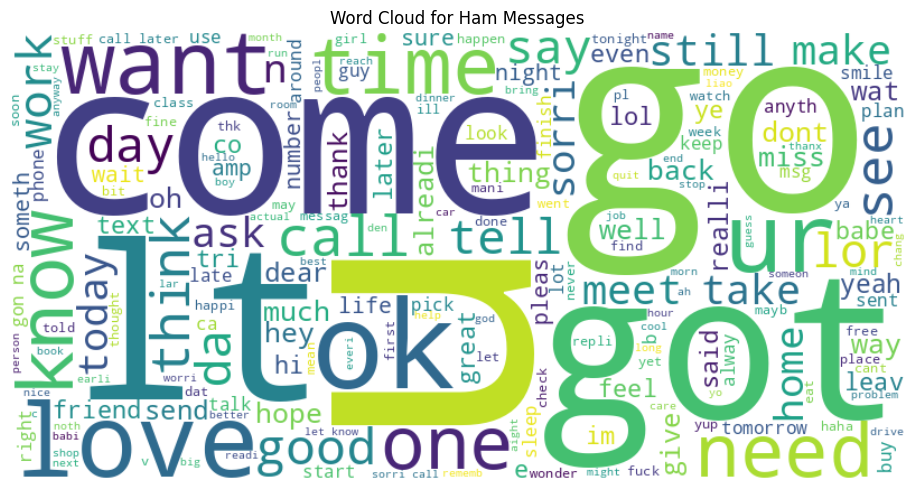

In [70]:
# Show keywords of spam and ham using word clouds
from wordcloud import WordCloud
spam_text = " ".join(df[df["Label"] == "spam"]["SMS_TEXT"].fillna("").astype(str))
ham_text = " ".join(df[df["Label"] == "ham"]["SMS_TEXT"].fillna("").astype(str))
spam_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(spam_text)
ham_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(12, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Spam Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.title("Word Cloud for Ham Messages")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Reflexión y análisis
Responda las siguientes preguntas:

• ¿Qué cambios son más notorios entre los indicadores antes y después del
preprocesamiento?

• Respecto a las 20 palabras más frecuentes en ambos grupos:

    o ¿Hay palabras en común entre spam y ham?
    o ¿Qué palabras son exclusivas de cada clase?
    o ¿Qué información o patrones puede deducir de estas diferencias?

• Según su análisis exploratorio, ¿qué características del texto podrían ser útiles para
distinguir entre un mensaje spam y uno ham?

### ¿Qué cambios son más notorios entre los indicadores antes y después del
preprocesamiento?
Principalmente entre las palabras más frecuentes, ya que el preprocesamiento elimina palabras comunes (stopwords) y reduce las palabras a su raíz (stemming), estas son las que siempre aparecen en ambos grupos y son muy frecuentes, por lo que no aportan información relevante para diferenciar entre spam y ham. 
Además, el preprocesamiento puede revelar palabras clave que son más representativas de cada clase, lo que puede ayudar a identificar patrones específicos en los mensajes spam y ham.

### Respecto a las 20 palabras más frecuentes en ambos grupos:
#### ¿Hay palabras en común entre spam y ham?

Entre las palabras mas frecuentes en ambos grupos, es común encontrar palabras como 'ur', 'get', 'u', '2', 'call' y '4'.

In [71]:
# Common words between spam and ham
common_words = set(word for word, count in top_spam_words) & set(word for word, count in top_ham_words)
print("Common words between spam and ham:", common_words)

Common words between spam and ham: {'ur', 'get', 'u', '2', 'call', '4'}


#### ¿Qué palabras son exclusivas de cada clase?

In [72]:
# Top words exclusive to spam and ham
exclusive_spam_words = set(word for word, count in top_spam_words) - set(word for word, count in top_ham_words)
exclusive_ham_words = set(word for word, count in top_ham_words) - set(word for word, count in top_spam_words)
print("Exclusive words in spam messages:", exclusive_spam_words)
print("Exclusive words in ham messages:", exclusive_ham_words)

Exclusive words in spam messages: {'send', 'text', 'repli', 'mobil', 'nokia', 'txt', 'award', 'free', 'tone', 'claim', 'prize', 'servic', 'stop', 'new'}
Exclusive words in ham messages: {'day', 'good', 'go', 'love', 'time', 'like', 'know', 'need', 'come', 'got', 'want', 'one', 'ok', 'lt'}


#### ¿Qué información o patrones puede deducir de estas diferencias?
Las palabras exclusivas de cada clase pueden indicar temas o características específicas asociadas con el spam o el ham. Por ejemplo, las palabras exclusivas del spam podrían incluir términos relacionados con ofertas, promociones, o lenguaje persuasivo, mientras que las palabras exclusivas del ham podrían estar relacionadas con conversaciones cotidianas, saludos, o temas personales. Estas diferencias pueden ayudar a identificar patrones de lenguaje que son más comunes en los mensajes spam en comparación con los mensajes ham.

### Según su análisis exploratorio, ¿qué características del texto podrían ser útiles para
distinguir entre un mensaje spam y uno ham?
Las palabras como Free, Call, Ur, Get, 2, 4, etc., que son más frecuentes en los mensajes spam, podrían ser características útiles para distinguir entre un mensaje spam y uno ham. Además, la longitud del mensaje y la presencia de ciertos patrones de lenguaje o palabras clave también podrían ser indicadores importantes para la clasificación automática de mensajes.

## 6. Clasificador Bayesiano paso a paso

Usando las fórmulas del Teorema de Bayes para clasificar un mensaje como SPAM o HAM.

**Para una sola palabra W:**

$$P(S|W) = \frac{P(W|S)\,P(S)}{P(W|S)\,P(S) + P(W|H)\,P(H)}$$

Donde $P_i = P(S|W_i)$ es la probabilidad individual de cada palabra.

**Para múltiples palabras $W_1$ a $W_n$:**

$$P(S|\mathbf{W}) = \frac{P_1 P_2 \cdots P_n}{P_1 P_2 \cdots P_n + (1-P_1)(1-P_2)\cdots(1-P_n)}$$

**Pasos:**
1. Calcular probabilidades a priori: P(S) y P(H)
2. Calcular P(W|S) y P(W|H) para cada palabra (con suavizado de Laplace)
3. Calcular P(S|Wi) por palabra usando Bayes
4. Combinar todas las probabilidades con la fórmula multi-palabra

In [73]:
from collections import defaultdict
from functools import reduce

# ── Paso 1: Probabilidades a priori ──────────────────────────────
n_total = len(df)
n_spam  = (df["Label"] == "spam").sum()
n_ham   = (df["Label"] == "ham").sum()

P_S = n_spam / n_total
P_H = n_ham  / n_total

print("=== Paso 1: Probabilidades a priori ===")
print(f"  Total mensajes : {n_total}")
print(f"  Spam           : {n_spam}  →  P(S) = {n_spam}/{n_total} = {P_S:.4f}")
print(f"  Ham            : {n_ham}  →  P(H) = {n_ham}/{n_total} = {P_H:.4f}")

# ── Paso 2: Frecuencia de palabras por clase (nivel mensaje) ──────
# Contamos cuántos mensajes de cada clase contienen cada palabra
word_in_spam = defaultdict(int)
word_in_ham  = defaultdict(int)

for msg in df[df["Label"] == "spam"]["SMS_TEXT"]:
    for word in set(str(msg).split()):
        word_in_spam[word] += 1

for msg in df[df["Label"] == "ham"]["SMS_TEXT"]:
    for word in set(str(msg).split()):
        word_in_ham[word] += 1

print("\n=== Paso 2: Cálculo de likelihoods con suavizado de Laplace ===")
print("  P(W|S) = (mensajes spam con W + 1) / (total spam + 2)")
print("  P(W|H) = (mensajes ham  con W + 1) / (total ham  + 2)")

def p_word_given_spam(word):
    return (word_in_spam[word] + 1) / (n_spam + 2)

def p_word_given_ham(word):
    return (word_in_ham[word] + 1) / (n_ham + 2)

# ── Paso 3: P(S|W) por palabra via Bayes ─────────────────────────
def p_spam_given_word(word):
    p_ws = p_word_given_spam(word)
    p_wh = p_word_given_ham(word)
    return (p_ws * P_S) / (p_ws * P_S + p_wh * P_H)

# ── Preprocesamiento (igual al inciso 3) ─────────────────────────
def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [w.lower() for w in tokens]
    tokens = [w for w in tokens if w.isalnum()]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    return tokens

# ── Clasificador completo con paso a paso ────────────────────────
def classify(text):
    tokens = preprocess(text)
    print(f'\nTexto ingresado : "{text}"')
    print(f"Tokens tras preprocesamiento: {tokens}\n")

    print("=== Paso 3: P(S|Wi) por cada palabra ===")
    probs = []
    for word in tokens:
        p_ws = p_word_given_spam(word)
        p_wh = p_word_given_ham(word)
        p_sw = p_spam_given_word(word)
        probs.append(p_sw)
        print(f"  '{word}':")
        print(f"    P(W|S) = ({word_in_spam[word]}+1)/({n_spam}+2) = {p_ws:.6f}")
        print(f"    P(W|H) = ({word_in_ham[word]}+1)/({n_ham}+2)  = {p_wh:.6f}")
        print(f"    P(S|W) = ({p_ws:.4f} × {P_S:.4f}) / ({p_ws:.4f}×{P_S:.4f} + {p_wh:.4f}×{P_H:.4f}) = {p_sw:.6f}")

    if not probs:
        print("  Sin tokens reconocidos — resultado indeterminado.")
        return

    # Paso 4: fórmula multi-palabra
    prod_pi    = reduce(lambda a, b: a * b, probs)
    prod_1mpi  = reduce(lambda a, b: a * b, [1 - p for p in probs])
    p_final    = prod_pi / (prod_pi + prod_1mpi)

    print("\n=== Paso 4: Probabilidad combinada (fórmula multi-palabra) ===")
    print(f"  P1 × P2 × … × Pn           = {prod_pi:.4e}")
    print(f"  (1-P1)×(1-P2)×…×(1-Pn)    = {prod_1mpi:.4e}")
    print(f"  P(S|W1…Wn) = {prod_pi:.4e} / ({prod_pi:.4e} + {prod_1mpi:.4e})")
    print(f"             = {p_final:.6f}")
    label = "SPAM" if p_final >= 0.5 else "HAM"
    print(f"\n  ► Clasificación final: {label}  (umbral = 0.5)")
    return p_final

# ── Pruebas ───────────────────────────────────────────────────────
print("\n" + "="*65)
classify("Congratulations! You won a FREE prize, claim your reward now!")
print("\n" + "="*65)
classify("Hey, are you coming to dinner tonight?")
print("\n" + "="*65)
classify("WINNER! Call now to claim your FREE holiday!")

=== Paso 1: Probabilidades a priori ===
  Total mensajes : 5564
  Spam           : 746  →  P(S) = 746/5564 = 0.1341
  Ham            : 4818  →  P(H) = 4818/5564 = 0.8659

=== Paso 2: Cálculo de likelihoods con suavizado de Laplace ===
  P(W|S) = (mensajes spam con W + 1) / (total spam + 2)
  P(W|H) = (mensajes ham  con W + 1) / (total ham  + 2)


Texto ingresado : "Congratulations! You won a FREE prize, claim your reward now!"
Tokens tras preprocesamiento: ['congratul', 'free', 'prize', 'claim', 'reward']

=== Paso 3: P(S|Wi) por cada palabra ===
  'congratul':
    P(W|S) = (14+1)/(746+2) = 0.020053
    P(W|H) = (2+1)/(4818+2)  = 0.000622
    P(S|W) = (0.0201 × 0.1341) / (0.0201×0.1341 + 0.0006×0.8659) = 0.833019
  'free':
    P(W|S) = (168+1)/(746+2) = 0.225936
    P(W|H) = (53+1)/(4818+2)  = 0.011203
    P(S|W) = (0.2259 × 0.1341) / (0.2259×0.1341 + 0.0112×0.8659) = 0.757432
  'prize':
    P(W|S) = (86+1)/(746+2) = 0.116310
    P(W|H) = (0+1)/(4818+2)  = 0.000207
    P(S|W) = (0.1163

np.float64(0.9999539540339519)

## 7. Evaluación del modelo

Se divide el dataset en **80% entrenamiento** y **20% prueba** (estratificado para mantener la proporción spam/ham).  
Las frecuencias de palabras se calculan **solo** con los datos de entrenamiento para evitar data leakage.

Se reportan:
- Matriz de confusión
- Precisión, Recall y F1-score
- Exploración de distintos valores de threshold

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)
import numpy as np

# 80/20 split estratificado
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["Label"]
)

print(f"Entrenamiento : {len(df_train)} mensajes  "
      f"(spam={( df_train['Label']=='spam').sum()}, ham={(df_train['Label']=='ham').sum()})")
print(f"Prueba        : {len(df_test)} mensajes  "
      f"(spam={(df_test['Label']=='spam').sum()}, ham={(df_test['Label']=='ham').sum()})")

# ── Recalcular probabilidades a priori con training set ──────────────────────
n_spam_tr = (df_train["Label"] == "spam").sum()
n_ham_tr  = (df_train["Label"] == "ham").sum()
n_total_tr = len(df_train)

P_S_tr = n_spam_tr / n_total_tr
P_H_tr = n_ham_tr  / n_total_tr

# ── Frecuencias de palabras (nivel mensaje) solo sobre entrenamiento ──────────
from collections import defaultdict
wi_spam = defaultdict(int)
wi_ham  = defaultdict(int)

for msg in df_train[df_train["Label"] == "spam"]["SMS_TEXT"]:
    for word in set(str(msg).split()):
        wi_spam[word] += 1

for msg in df_train[df_train["Label"] == "ham"]["SMS_TEXT"]:
    for word in set(str(msg).split()):
        wi_ham[word] += 1

# ── Funciones del clasificador (Laplace smoothing) ───────────────────────────
def _p_ws(w): return (wi_spam[w] + 1) / (n_spam_tr + 2)
def _p_wh(w): return (wi_ham[w]  + 1) / (n_ham_tr  + 2)

def classify_prob(text):
    """Devuelve P(SPAM | texto) usando log-espacio para estabilidad numérica."""
    tokens = preprocess(str(text))
    if not tokens:
        return 0.5
    # P(S|Wi) para cada token
    probs = [(_p_ws(w) * P_S_tr) / (_p_ws(w) * P_S_tr + _p_wh(w) * P_H_tr)
             for w in tokens]
    # log-espacio para evitar underflow al multiplicar muchos valores pequeños
    log_num = sum(np.log(p   + 1e-300) for p in probs)
    log_den = sum(np.log(1-p + 1e-300) for p in probs)
    return 1.0 / (1.0 + np.exp(log_den - log_num))

# ── Clasificar todo el test set ──────────────────────────────────────────────
y_true  = (df_test["Label"] == "spam").astype(int).values
y_probs = np.array([classify_prob(t) for t in df_test["SMS_TEXT"]])

print("\nProbabilidades calculadas para el test set.")
print(f"  Min P(spam) = {y_probs.min():.4f}  |  Max P(spam) = {y_probs.max():.4f}")

Entrenamiento : 4451 mensajes  (spam=597, ham=3854)
Prueba        : 1113 mensajes  (spam=149, ham=964)

Probabilidades calculadas para el test set.
  Min P(spam) = 0.0000  |  Max P(spam) = 1.0000


=== Métricas con threshold = 0.5 ===
              precision    recall  f1-score   support

         HAM       0.96      0.99      0.97       964
        SPAM       0.94      0.71      0.81       149

    accuracy                           0.96      1113
   macro avg       0.95      0.85      0.89      1113
weighted avg       0.95      0.96      0.95      1113



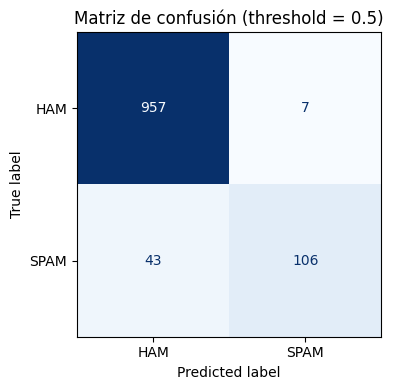

  TP (spam detectado correctamente) : 106
  TN (ham  detectado correctamente) : 957
  FP (ham  clasificado como spam)   : 7  ← falsa alarma
  FN (spam clasificado como ham)    : 43  ← spam que pasó


In [75]:
# ── Métricas con threshold por defecto (0.5) ────────────────────────────────
THRESHOLD = 0.5
y_pred = (y_probs >= THRESHOLD).astype(int)

print(f"=== Métricas con threshold = {THRESHOLD} ===")
print(classification_report(y_true, y_pred, target_names=["HAM", "SPAM"]))

# ── Matriz de confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HAM", "SPAM"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusión (threshold = {THRESHOLD})")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  TP (spam detectado correctamente) : {tp}")
print(f"  TN (ham  detectado correctamente) : {tn}")
print(f"  FP (ham  clasificado como spam)   : {fp}  ← falsa alarma")
print(f"  FN (spam clasificado como ham)    : {fn}  ← spam que pasó")

 Threshold  Precision   Recall       F1     FP     FN
-------------------------------------------------------
      0.05      0.627    0.812    0.708     72     28
      0.10      0.730    0.799    0.763     44     30
      0.15      0.801    0.785    0.793     29     32
      0.20      0.831    0.758    0.793     23     36
      0.25      0.848    0.752    0.797     20     37
      0.30      0.853    0.738    0.791     19     39
      0.35      0.872    0.732    0.796     16     40
      0.40      0.878    0.725    0.794     15     41
      0.45      0.884    0.718    0.793     14     42
      0.50      0.938    0.711    0.809      7     43
      0.55      0.955    0.711    0.815      5     43
      0.60      0.972    0.705    0.817      3     44
      0.65      0.972    0.698    0.812      3     45
      0.70      0.972    0.698    0.812      3     45
      0.75      0.981    0.698    0.816      2     45
      0.80      0.990    0.691    0.814      1     46
      0.85      0.990    0

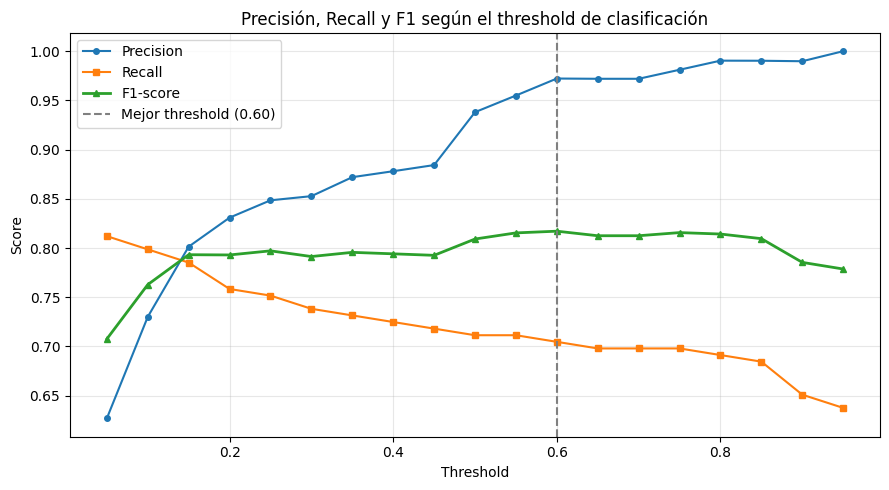

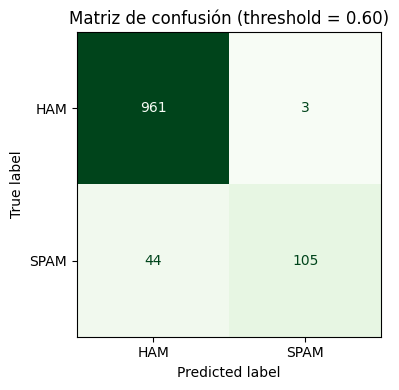

In [76]:
# ── Exploración de thresholds ────────────────────────────────────────────────
thresholds = np.arange(0.05, 1.0, 0.05)
precisions, recalls, f1s = [], [], []

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}  {'FP':>5}  {'FN':>5}")
print("-" * 55)
for t in thresholds:
    yp = (y_probs >= t).astype(int)
    p  = precision_score(y_true, yp, zero_division=0)
    r  = recall_score(y_true, yp, zero_division=0)
    f1 = f1_score(y_true, yp, zero_division=0)
    _, fp_t, fn_t, _ = confusion_matrix(y_true, yp, labels=[0,1]).ravel()
    precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f"{t:>10.2f} {p:>10.3f} {r:>8.3f} {f1:>8.3f}  {fp_t:>5}  {fn_t:>5}")

best_idx = int(np.argmax(f1s))
best_t   = thresholds[best_idx]
print(f"\n► Mejor threshold por F1: {best_t:.2f}  "
      f"(Precision={precisions[best_idx]:.3f}, Recall={recalls[best_idx]:.3f}, F1={f1s[best_idx]:.3f})")

# ── Gráfica ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label="Precision", marker="o", markersize=4)
plt.plot(thresholds, recalls,   label="Recall",    marker="s", markersize=4)
plt.plot(thresholds, f1s,       label="F1-score",  marker="^", markersize=4, linewidth=2)
plt.axvline(best_t, color="gray", linestyle="--", label=f"Mejor threshold ({best_t:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precisión, Recall y F1 según el threshold de clasificación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Mostrar matriz de confusión con el mejor threshold ───────────────────────
y_pred_best = (y_probs >= best_t).astype(int)
cm_best = confusion_matrix(y_true, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["HAM", "SPAM"]).plot(
    ax=ax, colorbar=False, cmap="Greens"
)
ax.set_title(f"Matriz de confusión (threshold = {best_t:.2f})")
plt.tight_layout()
plt.show()